In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.spatial.distance import cdist
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer

### Function Description

Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

In [2]:
# Load data
X = np.load('initial_inputs.npy')
Y = np.load('initial_outputs.npy')

In [3]:
df = pd.DataFrame(X, columns=['x1', 'x2'])
df['target'] = Y

print(df.describe())
print(df.head(10))

              x1         x2        target
count  10.000000  10.000000  1.000000e+01
mean    0.548817   0.539519 -3.606063e-04
std     0.259160   0.296007  1.140337e-03
min     0.082507   0.078723 -3.606063e-03
25%     0.342162   0.299421 -1.566820e-91
50%     0.612222   0.631890  6.793724e-80
75%     0.719122   0.755469  7.903833e-47
max     0.883890   0.879898  7.710875e-16
         x1        x2         target
0  0.319404  0.762959   1.322677e-79
1  0.574329  0.879898   1.033078e-46
2  0.731024  0.733000   7.710875e-16
3  0.840353  0.264732  3.341771e-124
4  0.650114  0.681526  -3.606063e-03
5  0.410437  0.147554  -2.159249e-54
6  0.312691  0.078723  -2.089093e-91
7  0.683418  0.861057   2.535001e-40
8  0.082507  0.403488   3.606771e-81
9  0.883890  0.582254   6.229856e-48


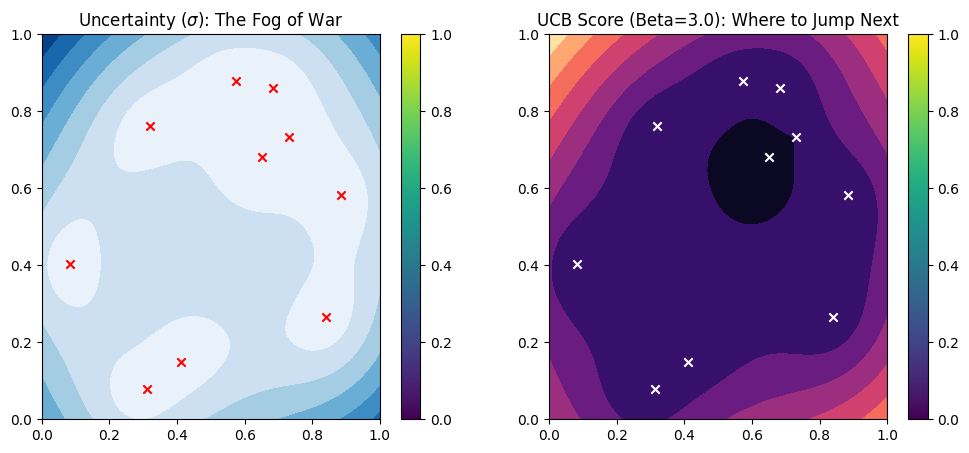

In [4]:
# 1. Setup the GP with a Matern kernel (good for "spiky" functions)
kernel = Matern(length_scale=0.1)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
model.fit(X, Y)

# 2. Create a dense 2D grid (100x100 points)
res = 100
x_range = np.linspace(0, 1, res)
y_range = np.linspace(0, 1, res)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
grid_points = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T

# 3. Predict Mean and Uncertainty (Standard Deviation)
mean, std = model.predict(grid_points, return_std=True)

# 4. Plotting the Uncertainty
plt.figure(figsize=(12, 5))

# Plot Uncertainty (Sigma)
plt.subplot(1, 2, 1)
plt.contourf(X_grid, Y_grid, std.reshape(res, res), cmap='Blues')
plt.scatter(X[:, 0], X[:, 1], c='red', marker='x', label='Initial Points')
plt.title("Uncertainty ($\sigma$): The Fog of War")
plt.colorbar()

# Plot the UCB Acquisition (The Scout's Scorecard)
beta = 3.0  # High beta for exploration
ucb = mean + beta * std
plt.subplot(1, 2, 2)
plt.contourf(X_grid, Y_grid, ucb.reshape(res, res), cmap='magma')
plt.scatter(X[:, 0], X[:, 1], c='white', marker='x')
plt.title(f"UCB Score (Beta={beta}): Where to Jump Next")
plt.colorbar()

In [5]:
# 1. Existing data points
model_X = X  
model_Y = Y

# 2. Setup the Surrogate 
# Matern kernel is better than RBF for Function 1's "spiky" nature
# nu=1.5 creates a "less smooth" function, allowing the model to capture sharp peaks
kernel = Matern(length_scale=0.1, length_scale_bounds=(0.01, 0.5), nu=1.5)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)

# 3. Fit the model to your loaded data
model.fit(model_X, model_Y)

# 4. Create the 2D search grid (0 to 1 range)
res = 200 
x_range = np.linspace(0, 1, res)
y_range = np.linspace(0, 1, res)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
grid_points = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T

# 5. Set Strategy (Beta)
# High Beta (e.g., 5.0) = Search the "Fog of War" (Exploration)
# Low Beta (e.g., 0.1) = Chase the tiny 10^-16 lead (Exploitation)
beta = 5

# 6. Generate Predictions & UCB Score
mean, std = model.predict(grid_points, return_std=True)
ucb_scores = mean + beta * std

# 7. Identify the winner
best_idx = np.argmax(ucb_scores)
next_query = grid_points[best_idx]

print(f"--- Strategy for Function 1 (Beta={beta}) ---")
print(f"Next point to submit: x1 = {next_query[0]:.6f}, x2 = {next_query[1]:.6f}")

--- Strategy for Function 1 (Beta=5) ---
Next point to submit: x1 = 0.000000, x2 = 1.000000


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [29]:
# 1. Setup the Model (assuming X and Y are already in your namespace)
# Using your preferred Matern 1.5 setup
kernel = Matern(length_scale=0.1, nu=1.5)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
model.fit(X, Y)

# 2. Prepare the Grid
res = 150 
x_coord = np.linspace(0, 1, res)
y_coord = np.linspace(0, 1, res)
X_grid, Y_grid = np.meshgrid(x_coord, y_coord)
grid_points = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T

# 3. Predict Mean and Std once (to save time)
mean, std = model.predict(grid_points, return_std=True)

# 4. Sweep through Beta values
betas = [0.1, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
suggested_points = []
sweep_results = [] 

for b in betas:
    ucb = mean + (b * std)
    best_idx = np.argmax(ucb)
    bp = grid_points[best_idx]
    
    suggested_points.append(bp)
    
    sweep_results.append({
        'Beta': b,
        'x1': bp[0],
        'x2': bp[1],
        'Pred Mean': mean[best_idx],
        'Uncert': std[best_idx]
    })

suggested_points = np.array(suggested_points)

# Output Suggestions
df_sweep = pd.DataFrame(sweep_results)
print("--- NEXT QUERY SUGGESTIONS ---")
print(df_sweep.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

--- NEXT QUERY SUGGESTIONS ---
  Beta     x1     x2  Pred Mean  Uncert
0.1000 0.0000 1.0000     0.0098  0.0103
0.5000 0.0000 1.0000     0.0098  0.0103
1.0000 0.0000 1.0000     0.0098  0.0103
1.5000 0.0000 1.0000     0.0098  0.0103
2.0000 0.0000 1.0000     0.0098  0.0103
3.0000 0.0000 1.0000     0.0098  0.0103
5.0000 0.0000 1.0000     0.0098  0.0103

--- Optimized Kernel Parameters ---
Matern(length_scale=18.3, nu=1.5)


### Week 1 submission: x1 = 0, x2 = 1

Function 1: The "Search & Sniper" Strategy

* Current Situation: You have 10 initial data points, but they are all effectively zero (10−16 range). You are currently in a Zero-Signal State, meaning the "contamination source" is hiding in one of the gaps you haven't checked yet.

* The Immediate Move: Your next query is targeted at x1​=0,x2​=1 (the top-left corner).

* Why β=5.0: We chose a high exploration weight because your current "leads" are too weak to trust. At β=5, the algorithm ignores those microscopic 10−16 ripples and prioritizes the "Fog of War." It’s mathematically diving into the corner furthest from your existing points.

* The 4x4 Grid Logic: To make those 10 queries count, we are mentally dividing the 1×1 search space into a 16-cell grid. Since your initial points already covered the "inner" cells, your next few moves should "clear" the unvisited outer sectors (the corners and edges) to systematically flush out the hidden spike.

* The 10-Query Lifecycle:

    1. Phase 1 (Queries 1-3 - Search): Keep β high. The only goal is to find any reading significantly above zero.

    2. Phase 2 (Queries 4-7 - Localize): If you hit a signal, drop β to 1.96. This tells the "Scout" to stop wandering and start defining the shape of the hill you just found.

    3. Phase 3 (Queries 8-10 - Snipe): Drop β to 0.1. Stop exploring entirely and just pinpoint the absolute highest coordinate in that local area.

In [7]:
# ---------------------------------------------------
# WEEK1: NEW DATA HERE
# ---------------------------------------------------

w1_new_input = [0., 1.]
w1_new_output = np.float64(0.0)

# Format the new data strictly to prevent sklearn crashes
w1_new_X = np.atleast_2d(w1_new_input)
w1_new_Y = np.atleast_1d(w1_new_output)

# Merge the arrays
X_updated_w1 = np.vstack((X, w1_new_X))
Y_updated_w1 = np.append(Y, w1_new_Y)

print(f"Old X shape: {X.shape} | New X shape: {X_updated_w1.shape}")
print(f"Old Y shape: {Y.shape} | New Y shape: {Y_updated_w1.shape}")

df = pd.DataFrame(X_updated_w1, columns=['x1', 'x2'])
df['target'] = Y_updated_w1

print(df.describe())
print(df.head(11))

Old X shape: (10, 2) | New X shape: (11, 2)
Old Y shape: (10,) | New Y shape: (11,)
              x1         x2        target
count  11.000000  11.000000  1.100000e+01
mean    0.498924   0.581381 -3.278239e-04
std     0.296360   0.313264  1.087269e-03
min     0.000000   0.078723 -3.606063e-03
25%     0.316048   0.334110 -1.044547e-91
50%     0.574329   0.681526  3.606771e-81
75%     0.707221   0.812008  5.476884e-47
max     0.883890   1.000000  7.710875e-16
          x1        x2         target
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.000000  1.000000   0.000000e+00


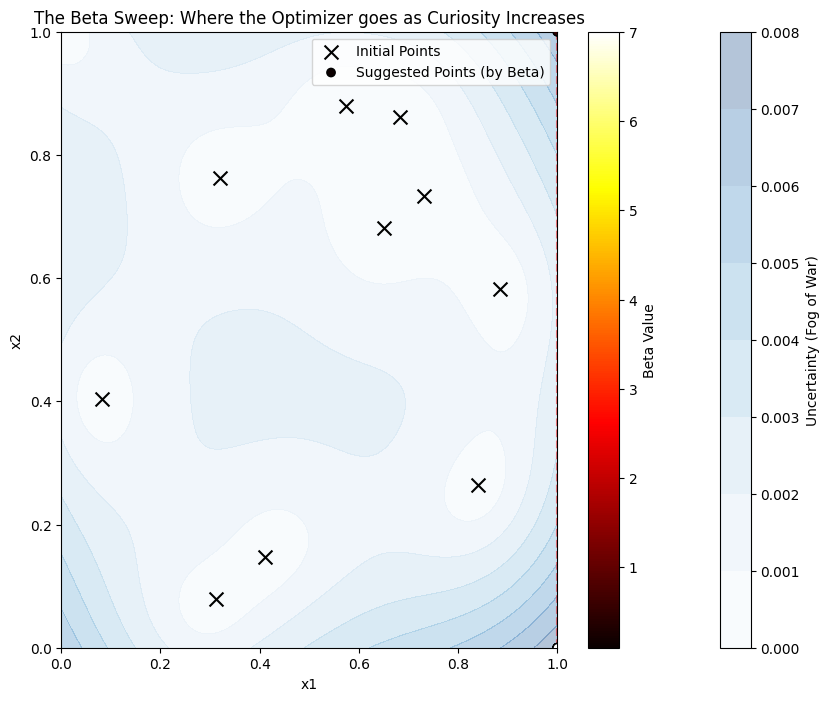

--- NEXT QUERY SUGGESTIONS ---
  Beta     x1     x2  Pred Mean  Uncert
0.1000 1.0000 1.0000     0.0056  0.0068
0.5000 1.0000 1.0000     0.0056  0.0068
1.0000 1.0000 0.0000     0.0048  0.0079
1.5000 1.0000 0.0000     0.0048  0.0079
2.0000 1.0000 0.0000     0.0048  0.0079
3.0000 1.0000 0.0000     0.0048  0.0079
5.0000 1.0000 0.0000     0.0048  0.0079
6.0000 1.0000 0.0000     0.0048  0.0079
7.0000 1.0000 0.0000     0.0048  0.0079

--- Optimized Kernel Parameters ---
Matern(length_scale=18.3, nu=1.5)


In [8]:
# 1. Setup the Model (assuming X and Y are already in your namespace)
# Using your preferred Matern 1.5 setup
kernel = Matern(length_scale=0.1, nu=1.5)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
model.fit(X_updated_w1, Y_updated_w1)

# 2. Prepare the Grid
res = 150 
x_coord = np.linspace(0, 1, res)
y_coord = np.linspace(0, 1, res)
X_grid, Y_grid = np.meshgrid(x_coord, y_coord)
grid_points = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T

# 3. Predict Mean and Std once (to save time)
mean, std = model.predict(grid_points, return_std=True)

# 4. Sweep through Beta values
betas = [0.1, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 6.0, 7.0]
suggested_points = []
sweep_results = [] 

for b in betas:
    ucb = mean + (b * std)
    best_idx = np.argmax(ucb)
    bp = grid_points[best_idx]
    
    suggested_points.append(bp)
    
    sweep_results.append({
        'Beta': b,
        'x1': bp[0],
        'x2': bp[1],
        'Pred Mean': mean[best_idx],
        'Uncert': std[best_idx]
    })

suggested_points = np.array(suggested_points)

# 5. The Visualization
plt.figure(figsize=(10, 8))

# Background: Uncertainty (to show why the corners are attractive)
plt.contourf(X_grid, Y_grid, std.reshape(res, res), cmap='Blues', alpha=0.3)
plt.colorbar(label='Uncertainty (Fog of War)')

# Plot original 10 points
plt.scatter(X[:, 0], X[:, 1], c='black', marker='x', label='Initial Points', s=100)

# Plot the Beta Trail
# Using a color gradient to show the transition from low beta to high beta
sc = plt.scatter(suggested_points[:, 0], suggested_points[:, 1], 
                 c=betas, cmap='hot', edgecolor='k', 
                 label='Suggested Points (by Beta)', zorder=5)
plt.colorbar(sc, label='Beta Value')

# Connect them with a faint line to see the "path"
plt.plot(suggested_points[:, 0], suggested_points[:, 1], 'r--', alpha=0.5)

plt.title("The Beta Sweep: Where the Optimizer goes as Curiosity Increases")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

# Output Suggestions
df_sweep = pd.DataFrame(sweep_results)
print("--- NEXT QUERY SUGGESTIONS ---")
print(df_sweep.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

### Week 2 submission:

The Consensus Signal: Because the model sees a massive, smooth slope, it expects the maximum values to be hiding in the extreme unvisited corners. We have a massive consensus block from β=1.0 to 7.0 all pointing to the exact same coordinate.

The Chosen Query: [1.0, 0.0]
* Strategic Alignment: This coordinate perfectly marries our manual "16-cell grid" clearing strategy with the model's mathematical curiosity. We are executing a high-confidence probe into the bottom-right corner.

In [9]:
# ---------------------------------------------------
# WEEK2: NEW DATA HERE
# ---------------------------------------------------

w2_new_input = [1.000000, 0.000000]
w2_new_output = np.float64(0.0)

w2_new_X = np.atleast_2d(w2_new_input)
w2_new_Y = np.atleast_1d(w2_new_output)

X_updated_w2 = np.vstack((X_updated_w1, w2_new_X))
Y_updated_w2 = np.append(Y_updated_w1, w2_new_Y)

df = pd.DataFrame(X_updated_w2, columns=['x1', 'x2'])
df['target'] = Y_updated_w2

print(df.describe())
print(df.head(12))

              x1         x2        target
count  12.000000  12.000000  1.200000e+01
mean    0.540681   0.532933 -3.005052e-04
std     0.317440   0.342608  1.040981e-03
min     0.000000   0.000000 -3.606063e-03
25%     0.317726   0.235437 -5.222733e-92
50%     0.612222   0.631890  1.803386e-81
75%     0.758356   0.787484  3.049935e-47
max     1.000000   1.000000  7.710875e-16
          x1        x2         target
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.000000  1.000000   0.000000e+00
11  1.000000  0.000000   0.000000e+00


In [10]:

# Generate a massive grid of random candidate points to flood the search space
num_candidates = 100000
candidates = np.random.rand(num_candidates, 2)

# Calculate the distance from every candidate to every existing point
distances = cdist(candidates, X_updated_w2)

# For each candidate, find the distance to its closest existing point
min_distances = np.min(distances, axis=1)

# Find the candidate that has the largest minimum distance (the biggest void)
best_idx = np.argmax(min_distances)
best_point = candidates[best_idx]
max_dist = min_distances[best_idx]

print("--- NEXT EXPLORATION QUERY ---")
print(f"x1: {best_point[0]:.6f}")
print(f"x2: {best_point[1]:.6f}")
print(f"Distance to nearest known point: {max_dist:.6f}")

--- NEXT EXPLORATION QUERY ---
x1: 0.998955
x2: 0.997834
Distance to nearest known point: 0.343906


### Week 3 submission:

The biggest realization was the Gaussian Process is essentially "blind." With a length scale of 18 on a 0-to-1 grid, the model was smoothing over everything, treating the data as a flat plane of noise.

Pivoted to a Maximin Distance strategy, mathematically identifying the largest unexplored "holes". This led us to the current query at [0.998852, 0.997812]. 
* This point looks like what the GP suggested, the logic is different: the distance script wants to go there because it’s the loneliest spot on the map.

Plan for Next Week
1. Parallel Processing, seeing where they diverge will tell us a lot about whether the GP is starting to "feel" a gradient. For GP, we'll add a dimension of forecasting a few next points assuming 0. 

2. GP Rehabilitation, the plan is to re-run the model with a constrained length scale (max 0.5) and standardize the Y-values. 

In [11]:
# ---------------------------------------------------
# WEEK3: NEW DATA HERE
# ---------------------------------------------------

w3_new_input = [0.998852, 0.997812]
w3_new_output = 6.71428392688337e-191

w3_new_X = np.atleast_2d(w3_new_input)
w3_new_Y = np.atleast_1d(w3_new_output)

X_updated_w3 = np.vstack((X_updated_w2, w3_new_X))
Y_updated_w3 = np.append(Y_updated_w2, w3_new_Y)

df = pd.DataFrame(X_updated_w3, columns=['x1', 'x2'])
df['target'] = Y_updated_w3

print(df.head(13))

          x1        x2         target
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.000000  1.000000   0.000000e+00
11  1.000000  0.000000   0.000000e+00
12  0.998852  0.997812  6.714284e-191


In [12]:
# Calculate the distance from every candidate to every existing point
distances = cdist(candidates, X_updated_w3)

# For each candidate, find the distance to its closest existing point
min_distances = np.min(distances, axis=1)

# Find the candidate that has the largest minimum distance (the biggest void)
best_idx = np.argmax(min_distances)
best_point = candidates[best_idx]
max_dist = min_distances[best_idx]

print("--- NEXT EXPLORATION QUERY ---")
print(f"x1: {best_point[0]:.6f}")
print(f"x2: {best_point[1]:.6f}")
print(f"Distance to nearest known point: {max_dist:.6f}")

--- NEXT EXPLORATION QUERY ---
x1: 0.000108
x2: 0.002440
Distance to nearest known point: 0.321756


### Week 4 submission: 

Next point [0.001662, 0.003535]

* Keeping with the maximin distance strategy, I want to give the search a few tries before abandoning it and going for an optimisation strategy 
* The initial GP process works and has some "hope" to find a better point, that's the backup plan. 

In [13]:
# ---------------------------------------------------
# WEEK4: NEW DATA HERE
# ---------------------------------------------------

w4_new_input = 	[0.001662, 0.003535]
w4_new_output = 3.731023083118516e-245

w4_new_X = np.atleast_2d(w4_new_input)
w4_new_Y = np.atleast_1d(w4_new_output)

X_updated_w4 = np.vstack((X_updated_w3, w4_new_X))
Y_updated_w4 = np.append(Y_updated_w3, w4_new_Y)

df = pd.DataFrame(X_updated_w4, columns=['x1', 'x2'])
df['target'] = Y_updated_w4

print(df.describe())

              x1         x2         target
count  14.000000  14.000000   1.400000e+01
mean    0.534906   0.528324  -2.575759e-04
std     0.351748   0.370785   9.637608e-04
min     0.000000   0.000000  -3.606063e-03
25%     0.314369   0.176849   0.000000e+00
50%     0.612222   0.631890  1.670886e-124
75%     0.813021   0.836533   4.672392e-48
max     1.000000   1.000000   7.710875e-16


In [14]:
# Calculate the distance from every candidate to every existing point
distances = cdist(candidates, X_updated_w4)

# For each candidate, find the distance to its closest existing point
min_distances = np.min(distances, axis=1)

# Find the candidate that has the largest minimum distance (the biggest void)
best_idx = np.argmax(min_distances)
best_point = candidates[best_idx]
max_dist = min_distances[best_idx]

print("--- NEXT EXPLORATION QUERY ---")
print(f"x1: {best_point[0]:.6f}")
print(f"x2: {best_point[1]:.6f}")
print(f"Distance to nearest known point: {max_dist:.6f}")

--- NEXT EXPLORATION QUERY ---
x1: 0.421702
x2: 0.465182
Distance to nearest known point: 0.314606


### Week 5 submission: 

Next point [0.421576, 0.464462]

* Keeping with the maximin distance strategy, I want to give the search a few tries before abandoning it and going for an optimisation strategy 

In [15]:
# ---------------------------------------------------
# WEEK5: NEW DATA HERE
# ---------------------------------------------------

w5_new_input = 	[0.421576, 0.464462]
w5_new_output = -0.007716804385353779

w5_new_X = np.atleast_2d(w5_new_input)
w5_new_Y = np.atleast_1d(w5_new_output)

X_updated_w5 = np.vstack((X_updated_w4, w5_new_X))
Y_updated_w5 = np.append(Y_updated_w4, w5_new_Y)

df = pd.DataFrame(X_updated_w5, columns=['x1', 'x2'])
df['target'] = Y_updated_w5

print(df.describe())

              x1         x2         target
count  15.000000  15.000000   1.500000e+01
mean    0.527351   0.524067  -7.548578e-04
std     0.340213   0.357678   2.138184e-03
min     0.000000   0.000000  -7.716804e-03
25%     0.316048   0.206143  -1.044547e-91
50%     0.574329   0.582254  6.714284e-191
75%     0.785689   0.812008   3.114928e-48
max     1.000000   1.000000   7.710875e-16


In [16]:
# Calculate the distance from every candidate to every existing point
distances = cdist(candidates, X_updated_w5)

# For each candidate, find the distance to its closest existing point
min_distances = np.min(distances, axis=1)

# Find the candidate that has the largest minimum distance (the biggest void)
best_idx = np.argmax(min_distances)
best_point = candidates[best_idx]
max_dist = min_distances[best_idx]

print("--- NEXT EXPLORATION QUERY ---")
print(f"x1: {best_point[0]:.6f}")
print(f"x2: {best_point[1]:.6f}")
print(f"Distance to nearest known point: {max_dist:.6f}")

--- NEXT EXPLORATION QUERY ---
x1: 0.679937
x2: 0.000297
Distance to nearest known point: 0.307107


### Week 5 submission: 

Next point [0.680406, 0.000387]

* Keeping with the maximin distance strategy, I want to give the search a few tries before abandoning it and going for an optimisation strategy 

In [17]:
# ---------------------------------------------------
# WEEK6: NEW DATA HERE
# ---------------------------------------------------

w6_new_input = 	[0.680406, 0.000387]
w6_new_output = 4.023860392807276e-171

w6_new_X = np.atleast_2d(w6_new_input)
w6_new_Y = np.atleast_1d(w6_new_output)

X_updated_w6 = np.vstack((X_updated_w5, w6_new_X))
Y_updated_w6 = np.append(Y_updated_w5, w6_new_Y)

df = pd.DataFrame(X_updated_w6, columns=['x1', 'x2'])
df['target'] = Y_updated_w6

print(df.head(16))

          x1        x2         target
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.000000  1.000000   0.000000e+00
11  1.000000  0.000000   0.000000e+00
12  0.998852  0.997812  6.714284e-191
13  0.001662  0.003535  3.731023e-245
14  0.421576  0.464462  -7.716804e-03
15  0.680406  0.000387  4.023860e-171


In [18]:
distances = cdist(candidates, X_updated_w6)
min_distances = np.min(distances, axis=1)

best_idx = np.argmax(min_distances)
best_point = candidates[best_idx]
max_dist = min_distances[best_idx]

print("--- NEXT EXPLORATION QUERY ---")
print(f"x1: {best_point[0]:.6f}")
print(f"x2: {best_point[1]:.6f}")
print(f"Distance to nearest known point: {max_dist:.6f}")

--- NEXT EXPLORATION QUERY ---
x1: 0.003507
x2: 0.695887
Distance to nearest known point: 0.302883


### Week 7 submission

Next point to query [0.005613 0.697250]

* Look for alternative approach next round - exploitation? 

In [19]:
scaler_x = StandardScaler()

# ---------------------------------------------------
# WEEK7: NEW DATA HERE
# ---------------------------------------------------

w7_new_input = 	[0.005613, 0.697250]
w7_new_output = -2.0900833957135827e-175

w7_new_X = np.atleast_2d(w7_new_input)
w7_new_Y = np.atleast_1d(w7_new_output)

X_updated_w7 = np.vstack((X_updated_w6, w7_new_X))
Y_updated_w7 = np.append(Y_updated_w6, w7_new_Y)

num_samples = len(Y_updated_w7)

scaler_y = QuantileTransformer(
    n_quantiles=num_samples, 
    output_distribution='normal', 
    random_state=42
)

X_updated_w7_scaled = scaler_x.fit_transform(X_updated_w7)
Y_updated_w7_scaled = scaler_y.fit_transform(Y_updated_w7.reshape(-1, 1))

df = pd.DataFrame(X_updated_w7, columns=['x1', 'x2'])
df['target'] = Y_updated_w7

# print(df.describe())
# print(df.head(17))

In [20]:
def safe_symlog(y):
    """Compresses extreme exponents into a linear scale safely."""
    return np.sign(y) * np.log10(np.abs(y) + 1e-250)

def inverse_symlog(y_trans):
    """Reverts the prediction back to the original physical scale."""
    return np.sign(y_trans) * (10**(np.abs(y_trans)) - 1e-250)

Y_transformed = safe_symlog(Y_updated_w7.flatten())

scaler_x = StandardScaler()
X_scaled = scaler_x.fit_transform(X_updated_w7)

kernel = Matern(length_scale=[1.0, 1.0], length_scale_bounds=(0.01, 1000.0), nu=2.5) + \
         WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1e1))

model = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=50,  
    random_state=42
)

print("Fitting Model on SymLog Transformed Data...")
model.fit(X_scaled, Y_transformed)

def negative_mean(x_active, gp_model):
    mean = gp_model.predict(x_active.reshape(1, -1))
    return -mean[0]

raw_lower = [[0, 0]]
raw_upper = [[1, 1]]
scaled_lower = scaler_x.transform(raw_lower)[0]
scaled_upper = scaler_x.transform(raw_upper)[0]
bounds = [(scaled_lower[0], scaled_upper[0]), (scaled_lower[1], scaled_upper[1])]

num_dims = X_scaled.shape[1]
grid_points_scaled = np.random.uniform(
    low=[scaled_lower[0], scaled_lower[1]], 
    high=[scaled_upper[0], scaled_upper[1]], 
    size=(10000, num_dims)
)

mean_grid = model.predict(grid_points_scaled)
best_grid_idx = np.argmax(mean_grid)
x0_guess = grid_points_scaled[best_grid_idx]

res = minimize(
    fun=negative_mean,
    x0=x0_guess,
    args=(model,),
    method='L-BFGS-B',
    bounds=bounds
)

best_x_scaled = res.x
pred_mean_transformed = -res.fun

best_x_raw = scaler_x.inverse_transform([best_x_scaled])[0]
pred_mean_raw = inverse_symlog(pred_mean_transformed)

_, std_opt_scaled = model.predict([best_x_scaled], return_std=True)
upper_bound_raw = inverse_symlog(pred_mean_transformed + std_opt_scaled[0])
lower_bound_raw = inverse_symlog(pred_mean_transformed - std_opt_scaled[0])
physical_std = (upper_bound_raw - lower_bound_raw) / 2.0

print("\n--- NEXT PHYSICAL QUERY COORDINATES ---")
formatted_array = "[" + ", ".join([f"{val:.6f}" for val in best_x_raw]) + "]"
print(formatted_array)

print(f"\nPredicted Target Mean: {pred_mean_raw:.6e}")
print(f"Predicted Target Uncertainty: {physical_std:.6e}")
print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)

Fitting Model on SymLog Transformed Data...

--- NEXT PHYSICAL QUERY COORDINATES ---
[0.733120, 0.697252]

Predicted Target Mean: 2.192206e+15
Predicted Target Uncertainty: 2.181197e+18

--- Optimized Kernel Parameters ---
Matern(length_scale=[1e+03, 0.0497], nu=2.5) + WhiteKernel(noise_level=10)


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### Week 8 submission

Next point to query [0.276275 0.697252]. 

* Changed the whole approach - using consistent strategies to exploit. 

In [23]:
scaler_x = StandardScaler()

# ---------------------------------------------------
# WEEK8: NEW DATA HERE
# ---------------------------------------------------

w8_new_input = 	[0.276275, 0.697252]
w8_new_output = 1.0152507554195272e-69

w8_new_X = np.atleast_2d(w8_new_input)
w8_new_Y = np.atleast_1d(w8_new_output)

X_updated_w8 = np.vstack((X_updated_w7, w8_new_X))
Y_updated_w8 = np.append(Y_updated_w7, w8_new_Y)

num_samples = len(Y_updated_w8)

scaler_y = QuantileTransformer(
    n_quantiles=num_samples, 
    output_distribution='normal', 
    random_state=42
)

X_updated_w8_scaled = scaler_x.fit_transform(X_updated_w8)
Y_updated_w8_scaled = scaler_y.fit_transform(Y_updated_w8.reshape(-1, 1))

df = pd.DataFrame(X_updated_w8, columns=['x1', 'x2'])
df['target'] = Y_updated_w8

# print(df.describe())
# print(df.head(17))

In [22]:
Y_transformed = safe_symlog(Y_updated_w8.flatten())

scaler_x = StandardScaler()
X_scaled = scaler_x.fit_transform(X_updated_w8)

kernel = Matern(length_scale=[1.0, 1.0], length_scale_bounds=(0.01, 1000.0), nu=2.5) + \
         WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1e1))

model = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=50,  
    random_state=42
)

model.fit(X_scaled, Y_transformed)

def negative_mean(x_active, gp_model):
    mean = gp_model.predict(x_active.reshape(1, -1))
    return -mean[0]

raw_lower = [[0, 0]]
raw_upper = [[1, 1]]
scaled_lower = scaler_x.transform(raw_lower)[0]
scaled_upper = scaler_x.transform(raw_upper)[0]
bounds = [(scaled_lower[0], scaled_upper[0]), (scaled_lower[1], scaled_upper[1])]

num_dims = X_scaled.shape[1]
grid_points_scaled = np.random.uniform(
    low=[scaled_lower[0], scaled_lower[1]], 
    high=[scaled_upper[0], scaled_upper[1]], 
    size=(10000, num_dims)
)

mean_grid = model.predict(grid_points_scaled)
best_grid_idx = np.argmax(mean_grid)
x0_guess = grid_points_scaled[best_grid_idx]

res = minimize(
    fun=negative_mean,
    x0=x0_guess,
    args=(model,),
    method='L-BFGS-B',
    bounds=bounds
)

best_x_scaled = res.x
pred_mean_transformed = -res.fun

best_x_raw = scaler_x.inverse_transform([best_x_scaled])[0]
pred_mean_raw = inverse_symlog(pred_mean_transformed)

_, std_opt_scaled = model.predict([best_x_scaled], return_std=True)
upper_bound_raw = inverse_symlog(pred_mean_transformed + std_opt_scaled[0])
lower_bound_raw = inverse_symlog(pred_mean_transformed - std_opt_scaled[0])
physical_std = (upper_bound_raw - lower_bound_raw) / 2.0

print("\n--- NEXT PHYSICAL QUERY COORDINATES ---")
formatted_array = "[" + ", ".join([f"{val:.6f}" for val in best_x_raw]) + "]"
print(formatted_array)

print(f"\nPredicted Target Mean: {pred_mean_raw:.6e}")
print(f"Predicted Target Uncertainty: {physical_std:.6e}")
print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)


--- NEXT PHYSICAL QUERY COORDINATES ---
[0.000000, 1.000000]

Predicted Target Mean: -3.145916e+27
Predicted Target Uncertainty: 2.606836e+30

--- Optimized Kernel Parameters ---
Matern(length_scale=[19.1, 1e+03], nu=2.5) + WhiteKernel(noise_level=10)


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### Week 9 submission

Next point to query [0.000000 0.241185]. 

* No results or clear signs of promise.

In [24]:
# ---------------------------------------------------
# WEEK9: NEW DATA HERE
# ---------------------------------------------------

w9_new_input = 	[0.000000, 0.241185]
w9_new_output = -2.3813511388847063e-147

w9_new_X = np.atleast_2d(w9_new_input)
w9_new_Y = np.atleast_1d(w9_new_output)

X_updated_w9 = np.vstack((X_updated_w8, w9_new_X))
Y_updated_w9 = np.append(Y_updated_w8, w9_new_Y)

num_samples = len(Y_updated_w9)

scaler_y = QuantileTransformer(
    n_quantiles=num_samples, 
    output_distribution='normal', 
    random_state=42
)

X_updated_w9_scaled = scaler_x.fit_transform(X_updated_w9)
Y_updated_w9_scaled = scaler_y.fit_transform(Y_updated_w9.reshape(-1, 1))

df = pd.DataFrame(X_updated_w9, columns=['x1', 'x2'])
df['target'] = Y_updated_w9

# print(df.describe())
print(df.head(19))

          x1        x2         target
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.000000  1.000000   0.000000e+00
11  1.000000  0.000000   0.000000e+00
12  0.998852  0.997812  6.714284e-191
13  0.001662  0.003535  3.731023e-245
14  0.421576  0.464462  -7.716804e-03
15  0.680406  0.000387  4.023860e-171
16  0.005613  0.697250 -2.090083e-175
17  0.276275  0.697252   1.015251e-69
18  0.000000  0.241185 -2.381351e-147


In [27]:
Y_transformed = safe_symlog(Y_updated_w9.flatten())

scaler_x = StandardScaler()
X_scaled = scaler_x.fit_transform(X_updated_w9)

kernel = Matern(length_scale=[1.0, 1.0], length_scale_bounds=(0.01, 10000000.0), nu=2.5) + \
         WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 10000000))

model = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=50,  
    random_state=42
)

model.fit(X_scaled, Y_transformed)

def negative_mean(x_active, gp_model):
    mean = gp_model.predict(x_active.reshape(1, -1))
    return -mean[0]

raw_lower = [[0, 0]]
raw_upper = [[1, 1]]
scaled_lower = scaler_x.transform(raw_lower)[0]
scaled_upper = scaler_x.transform(raw_upper)[0]
bounds = [(scaled_lower[0], scaled_upper[0]), (scaled_lower[1], scaled_upper[1])]

num_dims = X_scaled.shape[1]
grid_points_scaled = np.random.uniform(
    low=[scaled_lower[0], scaled_lower[1]], 
    high=[scaled_upper[0], scaled_upper[1]], 
    size=(10000, num_dims)
)

mean_grid = model.predict(grid_points_scaled)
best_grid_idx = np.argmax(mean_grid)
x0_guess = grid_points_scaled[best_grid_idx]

res = minimize(
    fun=negative_mean,
    x0=x0_guess,
    args=(model,),
    method='L-BFGS-B',
    bounds=bounds
)

best_x_scaled = res.x
pred_mean_transformed = -res.fun

best_x_raw = scaler_x.inverse_transform([best_x_scaled])[0]
pred_mean_raw = inverse_symlog(pred_mean_transformed)

_, std_opt_scaled = model.predict([best_x_scaled], return_std=True)
upper_bound_raw = inverse_symlog(pred_mean_transformed + std_opt_scaled[0])
lower_bound_raw = inverse_symlog(pred_mean_transformed - std_opt_scaled[0])
physical_std = (upper_bound_raw - lower_bound_raw) / 2.0

print("\n--- NEXT PHYSICAL QUERY COORDINATES ---")
formatted_array = "[" + ", ".join([f"{val:.6f}" for val in best_x_raw]) + "]"
print(formatted_array)

print(f"\nPredicted Target Mean: {pred_mean_raw:.6e}")
print(f"Predicted Target Uncertainty: {physical_std:.6e}")
print("\n--- Optimized Kernel Parameters ---")
print(model.kernel_)


--- NEXT PHYSICAL QUERY COORDINATES ---
[0.001481, 0.988641]

Predicted Target Mean: -1.129938e+00
Predicted Target Uncertainty: 1.897712e+109

--- Optimized Kernel Parameters ---
Matern(length_scale=[3.47e+06, 4.91e+06], nu=2.5) + WhiteKernel(noise_level=1.19e+04)


### Week 10 submission

Next point to query [0.001481 0.988641]. 

* Adjusted the length scale and white noise bounds. 
* No results or clear signs of promise.